# Power Analysis

## Statistical Power

When we do hypothesis testing, a low p-value gives us grounds to reject the Null hypothesis. Recall, a p-value is the probability of seeing data as extreme as (or more extreme than) what you observed, assuming the null hypothesis is true.
But how do we know if our study was actually capable of finding an effect in the first place? That is where the concept of statistical power comes in. Power is the probability that our test will successfully detect a real effect when one truly exists—in other words, the probability of correctly rejecting a false Null hypothesis.

Having clarity on statistical power is important because in real-world experiments, there can be errors when we are testing a hypothesis. For example, we can accidentally get a low p-value (making us reject the Null hypothesis) when actually there is no real effect. This, as we know, is called a **Type I error**. The probability of having a Type I error is denoted by alpha ($\alpha$).On the other hand, there is a possibility that a real effect exists, but our test fails to capture it—this is a **Type II error**. The probability of having a Type II error is denoted by beta ($\beta$).

With power analysis, we want to estimate the probability of successfully **catching an effect** when it is there. Notice this is the exact opposite (the complement) of beta (**missing an effect** when it is there). So, mathematically, $Power = 1 - \beta$.

Power tells you how good your detector is at detecting a real effect.
For example, 80% power means that, assuming the specified effect and other assumptions are correct, the study has an 80% chance of detecting that effect at the chosen significance level.

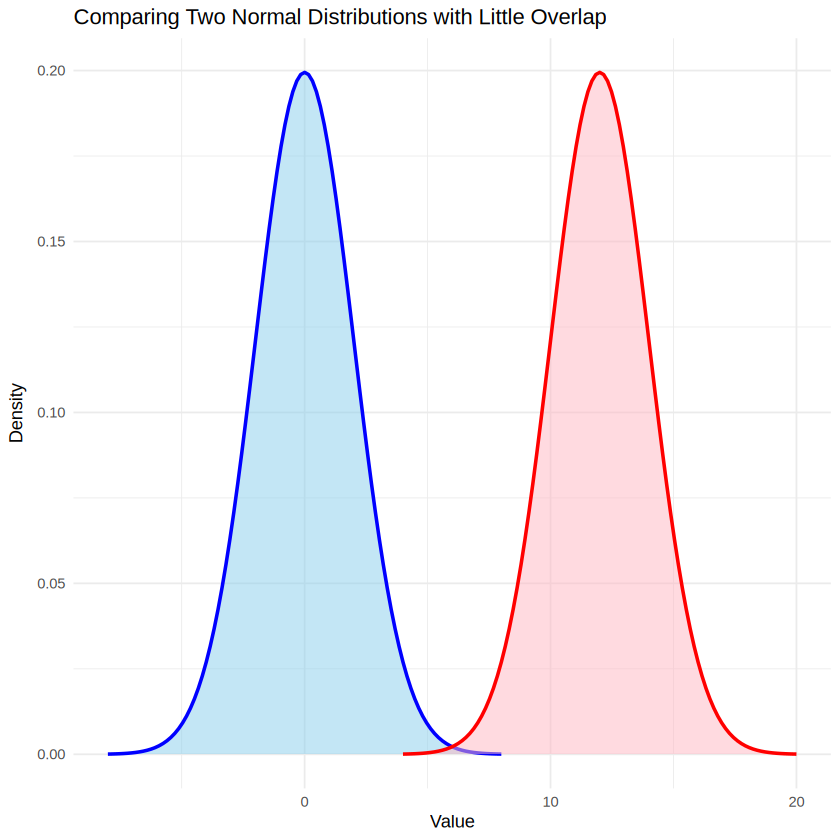

In [1]:
library(ggplot2)

# Create a blank plot spanning across both distributions with less overlap (from -8 to 20)
ggplot(data.frame(x = c(-8, 20)), aes(x = x)) +
  # First distribution (Mean = 0, sd = 2, restricted from -8 to 8)
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 1, xlim = c(-8, 8)) +

  # Second distribution shifted further right (Mean = 12, sd = 2, restricted from 4 to 20)
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(4, 20)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                color = "red", linewidth = 1, xlim = c(4, 20)) +

  labs(title = "Comparing Two Normal Distributions with Little Overlap",
       x = "Value",
       y = "Density") +
  theme_minimal()

In [2]:
#| include: false
install.packages("patchwork")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



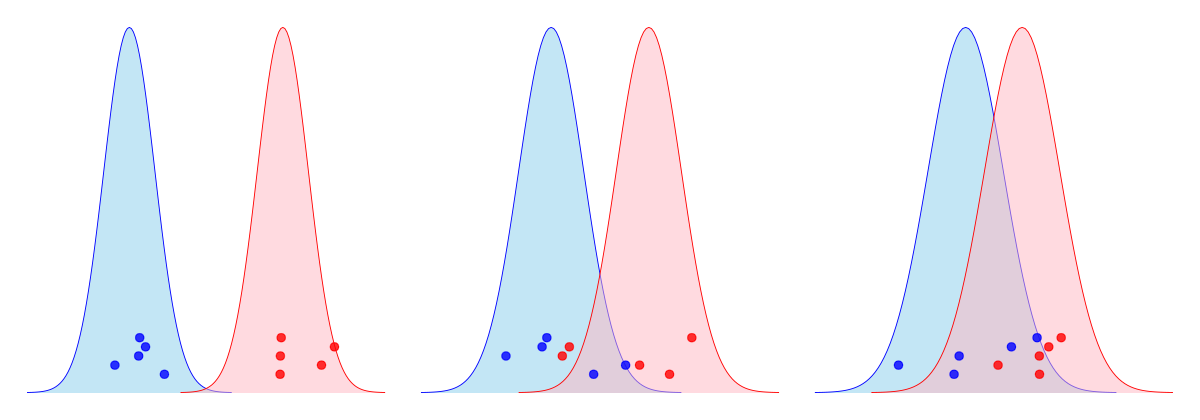

In [3]:
#| echo: false
library(ggplot2)
library(patchwork)
options(repr.plot.width = 10, repr.plot.height = 3.5)

# Set seed for reproducibility
set.seed(42)

# Point vertical alignment range (halved y-axis point range relative to graph height)
y_vals_middle <- seq(0.01, 0.03, length.out = 5)

# Helper function to generate random points strictly within a bounded interval
rnorm_bounded <- function(n, mean, sd, min_val, max_val) {
  safe_min <- min_val + 1.0 * sd
  safe_max <- max_val - 1.0 * sd

  pts <- c()
  while(length(pts) < n) {
    candidates <- rnorm(n - length(pts), mean = mean, sd = sd)
    pts <- c(pts, candidates[candidates >= safe_min & candidates <= safe_max])
  }
  return(pts)
}

# --- Left Plot: Little Overlap (Mean 0 vs Mean 12) ---
p1_blue_pts <- data.frame(x = rnorm_bounded(5, mean = 0, sd = 2, min_val = -8, max_val = 8), y = y_vals_middle)
p1_red_pts  <- data.frame(x = rnorm_bounded(5, mean = 12, sd = 2, min_val = 4, max_val = 20), y = y_vals_middle)

p1 <- ggplot(data.frame(x = c(-8, 20)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(4, 20)) +
  stat_function(fun = dnorm, args = list(mean = 12, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(4, 20)) +
  geom_point(data = p1_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p1_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# --- Middle Plot: Moderate Overlap (Mean 0 vs Mean 6) ---
p2_blue_pts <- data.frame(x = rnorm_bounded(5, mean = 0, sd = 2, min_val = -8, max_val = 8), y = y_vals_middle)
p2_red_pts  <- data.frame(x = rnorm_bounded(5, mean = 6, sd = 2, min_val = -2, max_val = 14), y = y_vals_middle)

p2 <- ggplot(data.frame(x = c(-8, 14)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 6, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(-2, 14)) +
  stat_function(fun = dnorm, args = list(mean = 6, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(-2, 14)) +
  geom_point(data = p2_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p2_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# --- Right Plot: Heavy Overlap (Mean 0 vs Mean 3) ---
# The midpoint between Mean 0 and Mean 3 is 1.5.
p3_blue_x <- c(
  rnorm_bounded(1, mean = 0, sd = 2, min_val = -8, max_val = 1.5),
  rnorm_bounded(4, mean = 0, sd = 2, min_val = -8, max_val = 8)
)
p3_red_x <- c(
  rnorm_bounded(1, mean = 3, sd = 2, min_val = 1.5, max_val = 11),
  rnorm_bounded(4, mean = 3, sd = 2, min_val = -5, max_val = 11)
)

p3_blue_pts <- data.frame(x = p3_blue_x, y = y_vals_middle)
p3_red_pts  <- data.frame(x = p3_red_x, y = y_vals_middle)

p3 <- ggplot(data.frame(x = c(-8, 11)), aes(x = x)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                geom = "area", fill = "skyblue", alpha = 0.5, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 0, sd = 2),
                color = "blue", linewidth = 0.25, xlim = c(-8, 8)) +
  stat_function(fun = dnorm, args = list(mean = 3, sd = 2),
                geom = "area", fill = "lightpink", alpha = 0.5, xlim = c(-5, 11)) +
  stat_function(fun = dnorm, args = list(mean = 3, sd = 2),
                color = "red", linewidth = 0.25, xlim = c(-5, 11)) +
  geom_point(data = p3_blue_pts, aes(x = x, y = y), color = "blue", size = 2, alpha = 0.8) +
  geom_point(data = p3_red_pts, aes(x = x, y = y), color = "red", size = 2, alpha = 0.8) +
  theme_void()

# Assemble side-by-side using patchwork
p1 + p2 + p3